# Ch6 EGARCH Data Pipeline — API 版

**目标**: 用 Python API 重建 thesis Ch6 EGARCH 模型的完整数据集

**数据源**:

| 类别 | 变量 | API |
|------|------|-----|
| 金融市场 | BTC, Gold, Oil, SP500, VIX, MSCI | yfinance |
| 利率 | 10Y T-Bond, 3M T-Bill | yfinance |
| 宏观 | CPI | FRED ✅ |
| 加密网络 | Hashrate, Volume, Addresses | blockchain.com API |
| 情绪 | Google Trends | pytrends (待实现) |

**原始 Thesis 数据范围**: 2015-01 至 2021-07  
**本次目标**: 2015-01 至 2026-02（扩展到最新）

**学习日期**: 2026-02-09

In [1]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
from pathlib import Path
from datetime import date
from dotenv import load_dotenv

# Jupyter kernel 不走 ~/.zshrc，环境变量需要手动加载
load_dotenv(Path("~/.secrets.env").expanduser())

# 全局参数
START = "2015-01-01"
END   = date.today().isoformat()   # 动态取最新日期
OUT_DIR = Path(".")                # 输出目录

print(f"Date range: {START} → {END}")
print("Ready")

Date range: 2015-01-01 → 2026-02-10
Ready


---
## Part 1: 金融市场数据 — yfinance

### 学习要点
- `yf.download()` 一次拉多个 ticker，返回 MultiIndex DataFrame
- `["Close"]` 取收盘价后用 `.droplevel("Price")` 去掉多余层级
- yfinance ticker 速查：
  - 指数：`^GSPC`(SP500), `^VIX`, `^TNX`(10Y yield), `^IRX`(3M yield)
  - 期货：`GC=F`(黄金), `CL=F`(原油)
  - ETF 代理：`URTH`(MSCI World)
  - 加密：`BTC-USD`

In [2]:
# 一次性下载所有 yfinance 数据
tickers = {
    "BTC-USD": "btc",
    "GC=F":    "gold",
    "CL=F":    "oil",
    "^GSPC":   "sp500",
    "^VIX":    "vix",
    "URTH":    "msci",     # MSCI World ETF proxy
    "^TNX":    "tbond",    # 10-Year Treasury yield
    "^IRX":    "tbill",    # 13-Week Treasury yield
}

raw = yf.download(list(tickers.keys()), start=START, end=END)
raw.head()

[*********************100%***********************]  8 of 8 completed


Price            Close                                                         \
Ticker         BTC-USD       CL=F         GC=F       URTH        ^GSPC   ^IRX   
Date                                                                            
2015-01-01  314.248993        NaN          NaN        NaN          NaN    NaN   
2015-01-02  315.032013  52.689999  1186.000000  58.335354  2058.199951  0.015   
2015-01-03  281.082001        NaN          NaN        NaN          NaN    NaN   
2015-01-04  264.195007        NaN          NaN        NaN          NaN    NaN   
2015-01-05  274.473999  50.040001  1203.900024  56.967541  2020.579956  0.003   

Price                               High             ...   Open             \
Ticker       ^TNX       ^VIX     BTC-USD       CL=F  ...   ^TNX       ^VIX   
Date                                                 ...                     
2015-01-01    NaN        NaN  320.434998        NaN  ...    NaN        NaN   
2015-01-02  2.123  17.790001  315.838989  55.110001  ...  2.197  17.760000   
2015-01-03    NaN        NaN  315.149994        NaN  ...    NaN        NaN   
2015-01-04    NaN        NaN  287.230011        NaN  ...    NaN        NaN   
2015-01-05  2.039  19.920000  278.341003  52.730000  ...  2.102  19.190001   

Price         Volume                                                         
Ticker       BTC-USD      CL=F   GC=F     URTH         ^GSPC ^IRX ^TNX ^VIX  
Date                                                                         
2015-01-01   8036550       NaN    NaN      NaN           NaN  NaN  NaN  NaN  
2015-01-02   7860650  268708.0  138.0  31100.0  2.708700e+09  0.0  0.0  0.0  
2015-01-03  33054400       NaN    NaN      NaN           NaN  NaN  NaN  NaN  
2015-01-04  55629100       NaN    NaN      NaN           NaN  NaN  NaN  NaN  
2015-01-05  43962800  375782.0  470.0  61100.0  3.799120e+09  0.0  0.0  0.0  

[5 rows x 40 columns]

In [3]:
# 提取 Close 价格，重命名列
# yfinance 返回 MultiIndex: (Price, Ticker)
prices = raw["Close"].rename(columns=tickers)

# droplevel 去掉 "Price" 层（如果存在）
if isinstance(prices.columns, pd.MultiIndex):
    prices = prices.droplevel(0, axis=1)

prices.head()

Ticker,btc,oil,gold,msci,sp500,tbill,tbond,vix
Date,,,,,,,,
2015-01-01,314.248993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,315.032013,52.689999,1186.000000,58.335354,2058.199951,0.015,2.123,17.790001
2015-01-03,281.082001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-04,264.195007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,274.473999,50.040001,1203.900024,56.967541,2020.579956,0.003,2.039,19.920000


In [4]:
# 检查每列的数据范围和缺失值
for col in prices.columns:
    valid = prices[col].dropna()
    start = valid.index.min().date()
    end   = valid.index.max().date()
    n_nan = prices[col].isna().sum()
    print(f"{col:10s} | {start} → {end} | N={len(valid):,} | NaN={n_nan}")

btc        | 2015-01-01 → 2026-02-09 | N=4,058 | NaN=0
oil        | 2015-01-02 → 2026-02-09 | N=2,792 | NaN=1266
gold       | 2015-01-02 → 2026-02-09 | N=2,791 | NaN=1267
msci       | 2015-01-02 → 2026-02-09 | N=2,792 | NaN=1266
sp500      | 2015-01-02 → 2026-02-09 | N=2,792 | NaN=1266
tbill      | 2015-01-02 → 2026-02-09 | N=2,791 | NaN=1267
tbond      | 2015-01-02 → 2026-02-09 | N=2,791 | NaN=1267
vix        | 2015-01-02 → 2026-02-09 | N=2,792 | NaN=1266


### BTC Volume

yfinance 的 BTC-USD 自带 Volume 列，单独提取出来。

注意：yfinance 的 Volume 是 USD 交易量（`price × coins`），和 thesis 里的可能有差异。

In [5]:
btc_volume = raw["Volume"]["BTC-USD"].rename("volume")
btc_volume.head()

Date
2015-01-01     8036550
2015-01-02     7860650
2015-01-03    33054400
2015-01-04    55629100
2015-01-05    43962800
Freq: D, Name: volume, dtype: int64

---
## Part 2: 加密网络数据 — blockchain.com API

### 学习要点
- `requests.get(url).json()` 获取 JSON
- API 返回 `{"values": [{"x": timestamp, "y": value}, ...]}`
- `pd.to_datetime(unit="s")` 把 Unix 时间戳转日期
- 链上数据是 ~日频但不连续，后面需要 `reindex` + `ffill`

In [6]:
import requests

def fetch_blockchain(chart_name: str, col_name: str) -> pd.Series:
    """Fetch a time series from blockchain.com Charts API."""
    url = f"https://api.blockchain.info/charts/{chart_name}"
    params = {"timespan": "all", "format": "json", "sampled": "false"}
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    data = resp.json()["values"]
    s = pd.DataFrame(data)
    s["date"] = pd.to_datetime(s["x"], unit="s")
    s = s.set_index("date")["y"].rename(col_name)
    return s

# 下载链上指标
hashrate    = fetch_blockchain("hash-rate", "hashrate")
n_addresses = fetch_blockchain("n-unique-addresses", "addresses")
n_tx        = fetch_blockchain("n-transactions", "n_tx")
revenue     = fetch_blockchain("miners-revenue", "revenue")

print(f"hashrate:    {hashrate.index.min().date()} → {hashrate.index.max().date()}, N={len(hashrate)}")
print(f"addresses:   {n_addresses.index.min().date()} → {n_addresses.index.max().date()}, N={len(n_addresses)}")
print(f"n_tx:        {n_tx.index.min().date()} → {n_tx.index.max().date()}, N={len(n_tx)}")
print(f"revenue:     {revenue.index.min().date()} → {revenue.index.max().date()}, N={len(revenue)}")

hashrate:    2009-01-03 → 2026-02-09, N=6244
addresses:   2009-01-03 → 2026-02-09, N=6219
n_tx:        2009-01-17 → 2026-02-09, N=6230
revenue:     2009-01-17 → 2026-02-09, N=6233


---
## Part 3: CPI — FRED API

### 学习要点
- CPI 是月度数据（每月一个值），需要 `reindex` + `ffill` 到日频
- API key 存在 `~/.secrets`（已 source 到环境变量），用 `os.environ["FRED_API_KEY"]` 读取
- **安全原则**：密钥不写入代码/notebook，通过环境变量注入
- FRED series ID: `CPIAUCSL` = CPI for All Urban Consumers (seasonally adjusted)

In [7]:
import os
from fredapi import Fred

fred = Fred(api_key=os.environ["FRED_API_KEY"])
cpi_monthly = fred.get_series("CPIAUCSL", observation_start=START)
cpi_monthly.name = "cpi"

print(f"CPI: {cpi_monthly.index.min().date()} → {cpi_monthly.index.max().date()}, N={len(cpi_monthly)}")
print(cpi_monthly.tail())

CPI: 2015-01-01 → 2025-12-01, N=132
2025-08-01    323.364
2025-09-01    324.368
2025-10-01        NaN
2025-11-01    325.031
2025-12-01    326.030
Name: cpi, dtype: float64


---
## Part 3.5: Google Trends — pytrends (分段拼接)

### 学习要点
- Google Trends 返回 **相对搜索热度** (0-100)，100 = 该时段内最高点
- 请求 >5 年 → 月频；<5 年 → 周频；<9 个月 → 日频
- **核心问题**：每次请求的 100 基准不同，所以分段请求后不能直接拼接
- **解决思路**：相邻段留 1 年重叠，用重叠区的中位数比值做缩放因子

```
段1 (2015-2019):  [..., 45, 50, 60, 55, ...]   ← 基准
段2 (2018-2023):  [..., 30, 33, 40, 37, ...]   ← 需要缩放
                        ↑ 重叠区 2018-2019
缩放因子 = median(段1重叠区) / median(段2重叠区)
段2_scaled = 段2 × 缩放因子
```

In [8]:
import time
from pytrends.request import TrendReq

pytrends = TrendReq()

# 分段请求：每段 <5 年（严格！），相邻段重叠 ~1 年
segments = [
    "2015-01-01 2019-06-30",   # 4.5 年 → 周频
    "2018-07-01 2022-12-31",   # 4.5 年 → 周频
    "2022-01-01 2026-02-28",   # 4 年   → 周频
]

raw_segments = []
for i, timeframe in enumerate(segments):
    for attempt in range(3):   # 最多重试 3 次
        try:
            pytrends.build_payload(["Bitcoin"], timeframe=timeframe)
            df_seg = pytrends.interest_over_time()
            break
        except Exception as e:
            wait = 30 * (attempt + 1)  # 30s, 60s, 90s
            print(f"  ⚠ Attempt {attempt+1} failed: {e}. Waiting {wait}s...")
            time.sleep(wait)
    else:
        print(f"  ✗ Segment {i+1} failed after 3 attempts, skipping")
        continue

    if not df_seg.empty:
        df_seg = df_seg["Bitcoin"]
        df_seg.index = df_seg.index.tz_localize(None)
        raw_segments.append(df_seg)
        print(f"Segment {i+1}: {df_seg.index.min().date()} → {df_seg.index.max().date()}, "
              f"N={len(df_seg)}, range=[{df_seg.min()}, {df_seg.max()}]")
    time.sleep(15)  # 段间等 15 秒，避免 429

print(f"\nTotal segments: {len(raw_segments)}")

Segment 1: 2014-12-28 → 2019-06-30, N=236, range=[2, 100]
Segment 2: 2018-07-01 → 2022-12-25, N=235, range=[9, 100]


/opt/homebrew/Caskroom/miniconda/base/envs/quant/lib/python3.11/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


Segment 3: 2021-12-26 → 2026-02-08, N=216, range=[22, 100]

Total segments: 3


In [9]:
def stitch_segments(segments: list[pd.Series]) -> pd.Series:
    """Normalize and stitch overlapping Google Trends segments into one series.
    
    Args:
        segments: list of Series, each with DatetimeIndex and 0-100 values.
                  Adjacent segments have ~1 year overlap.
    
    Returns:
        Single Series with consistent scale (segment 1 as base).
    """
    result = [segments[0]]
    for i in range(1, len(segments)):
        overlap_dates = segments[i-1].index.intersection(segments[i].index)
        scale = (segments[i-1][overlap_dates].median() /
                 segments[i][overlap_dates].median())
        scale_seg = scale * segments[i]
        scale_seg = scale_seg[scale_seg.index > overlap_dates.max()]
        result.append(scale_seg)
    return pd.concat(result).rename("gg")

gg = stitch_segments(raw_segments)
print(f"Google Trends: {gg.index.min().date()} → {gg.index.max().date()}, N={len(gg)}")
gg.tail(10)

Google Trends: 2014-12-28 → 2026-02-08, N=581


date
2025-12-07    30.000000
2025-12-14    30.666667
2025-12-21    24.666667
2025-12-28    24.000000
2026-01-04    24.666667
2026-01-11    24.666667
2026-01-18    24.666667
2026-01-25    26.666667
2026-02-01    58.000000
2026-02-08    42.000000
Name: gg, dtype: float64

---
## Part 4: 合并所有数据

### 学习要点
- 核心思路：以 BTC 的日期为「主轴」（因为 BTC 7×24 交易，日期最密）
- 其他序列 `reindex` 到 BTC 日期上 → 自动产生 NaN
- `ffill()` 前向填充（周末/假日用最近交易日的值）
- 最后 `dropna()` 清理开头几行

In [10]:
# 以 BTC 日期为主轴
btc_dates = prices["btc"].dropna().index

# 合并 yfinance 价格
df = prices.reindex(btc_dates)

# 合并 BTC Volume
df["volume"] = btc_volume.reindex(btc_dates)

# 合并链上数据（可能不是每天都有，需要 ffill）
for name, series in [("hashrate", hashrate), 
                      ("addresses", n_addresses),
                      ("n_tx", n_tx),
                      ("revenue", revenue)]:
    df[name] = series.reindex(btc_dates)

# 合并 CPI（如果有）
if cpi_monthly is not None:
    df["cpi"] = cpi_monthly.reindex(btc_dates)

# 合并 Google Trends（周频 → 日频，需要 ffill）
if gg is not None:
    df["gg"] = gg.reindex(btc_dates)

# 前向填充 + 清理
df = df.ffill().dropna()

print(f"Shape: {df.shape}")
print(f"Range: {df.index.min().date()} → {df.index.max().date()}")
df.head()

Shape: (4055, 15)
Range: 2015-01-04 → 2026-02-09


Ticker,btc,oil,gold,msci,sp500,tbill,tbond,vix,volume,hashrate,addresses,n_tx,revenue,cpi,gg
Date,,,,,,,,,,,,,,,
2015-01-04,264.195007,52.689999,1186.000000,58.335354,2058.199951,0.015,2.123,17.790001,55629100,335365.290092,207255.0,85694.0,1.632203e+06,234.747,2.0
2015-01-05,274.473999,50.040001,1203.900024,56.967541,2020.579956,0.003,2.039,19.920000,43962800,339405.835756,200612.0,95585.0,1.202039e+06,234.747,2.0
2015-01-06,286.188995,47.930000,1219.300049,56.210365,2002.609985,0.020,1.963,21.120001,23245700,317182.834605,179159.0,87821.0,1.361861e+06,234.747,2.0
2015-01-07,294.337006,48.650002,1210.599976,56.780277,2025.900024,0.020,1.954,19.309999,24866800,299000.379118,171674.0,89916.0,1.052470e+06,234.747,2.0
2015-01-08,283.348999,48.790001,1208.400024,58.042244,2062.139893,0.018,2.016,17.010000,19982500,272736.832304,197689.0,107132.0,1.383767e+06,234.747,2.0


In [11]:
# 确认没有 NaN
print("NaN per column:")
print(df.isna().sum())
print(f"\nTotal rows: {len(df):,}")

NaN per column:
Ticker
btc          0
oil          0
gold         0
msci         0
sp500        0
tbill        0
tbond        0
vix          0
volume       0
hashrate     0
addresses    0
n_tx         0
revenue      0
cpi          0
gg           0
dtype: int64

Total rows: 4,055


---
## Part 5: 计算变换（Log Returns / First Differences）

### 学习要点
- **Log return**: $r_t = \ln(P_t) - \ln(P_{t-1})$ — 用于价格、数量型变量
- **First difference**: $\Delta x_t = x_t - x_{t-1}$ — 用于利率(yield)、VIX、有界指数(Google Trends)
- 向量化：`np.log(df[cols]).diff()` 一行搞定

### 变量分类
| 变换 | 变量 | 原因 |
|------|------|------|
| `dln_` (log return) | btc, gold, oil, sp500, msci, hashrate, volume, addresses, n_tx, revenue, cpi | 价格/数量，log return 保证平稳 |
| `d_` (first diff) | tbond, tbill | yield 不是价格 |
| `d_` (first diff) | vix | 本身是 % 单位的波动率，不是价格 |
| `d_` (first diff) | gg | Google Trends 是有界指数(0-100)，log(0)=-inf |

In [12]:
# === Variable Classification ===
# Log return: 价格、数量型变量 → dln_x = ln(x_t) - ln(x_{t-1})
# First difference: 利率(yield)、指数型(VIX)、有界指数(Google Trends) → d_x = x_t - x_{t-1}
# CPI: 月度价格指数 → dln_cpi ≈ daily inflation proxy

# 价格/数量 → log return
price_cols = ["btc", "gold", "oil", "sp500", "msci",
              "hashrate", "volume", "addresses", "n_tx", "revenue"]

# 利率 + VIX + Google Trends → first difference
diff_cols = ["tbond", "tbill", "vix", "gg"]

# CPI → log return (价格指数，且无零值)
cpi_cols = ["cpi"]

# --- Log returns ---
log_ret = np.log(df[price_cols]).diff()
log_ret.columns = [f"dln_{c}" for c in log_ret.columns]

# --- First differences ---
first_diff = df[diff_cols].diff()
first_diff.columns = [f"d_{c}" for c in first_diff.columns]

# --- CPI log return ---
cpi_ret = np.log(df[cpi_cols]).diff()
cpi_ret.columns = [f"dln_{c}" for c in cpi_ret.columns]

# 合并到主 DataFrame
df = pd.concat([df, log_ret, first_diff, cpi_ret], axis=1).iloc[1:]

print(f"Final shape: {df.shape}")
print(f"\nColumns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

Final shape: (4054, 30)

Columns:
   1. btc
   2. oil
   3. gold
   4. msci
   5. sp500
   6. tbill
   7. tbond
   8. vix
   9. volume
  10. hashrate
  11. addresses
  12. n_tx
  13. revenue
  14. cpi
  15. gg
  16. dln_btc
  17. dln_gold
  18. dln_oil
  19. dln_sp500
  20. dln_msci
  21. dln_hashrate
  22. dln_volume
  23. dln_addresses
  24. dln_n_tx
  25. dln_revenue
  26. d_tbond
  27. d_tbill
  28. d_vix
  29. d_gg
  30. dln_cpi


---
## Part 6: 快速诊断

GARCH 建模前的 sanity check：
1. Returns 的描述统计（均值≈0、有偏度、厚尾/高峰度）
2. 自相关检验（收益率无自相关，但平方收益率有 → 波动聚集）

In [13]:
# BTC log return 描述统计
btc_ret = df["dln_btc"]
print(btc_ret.describe())
print(f"\nSkewness: {btc_ret.skew():.4f}")
print(f"Kurtosis: {btc_ret.kurtosis():.4f}  (normal = 3)")

count    4054.000000
mean        0.001377
std         0.035443
min        -0.464730
25%        -0.012228
50%         0.001215
75%         0.015901
max         0.225119
Name: dln_btc, dtype: float64

Skewness: -0.7380
Kurtosis: 11.9874  (normal = 3)


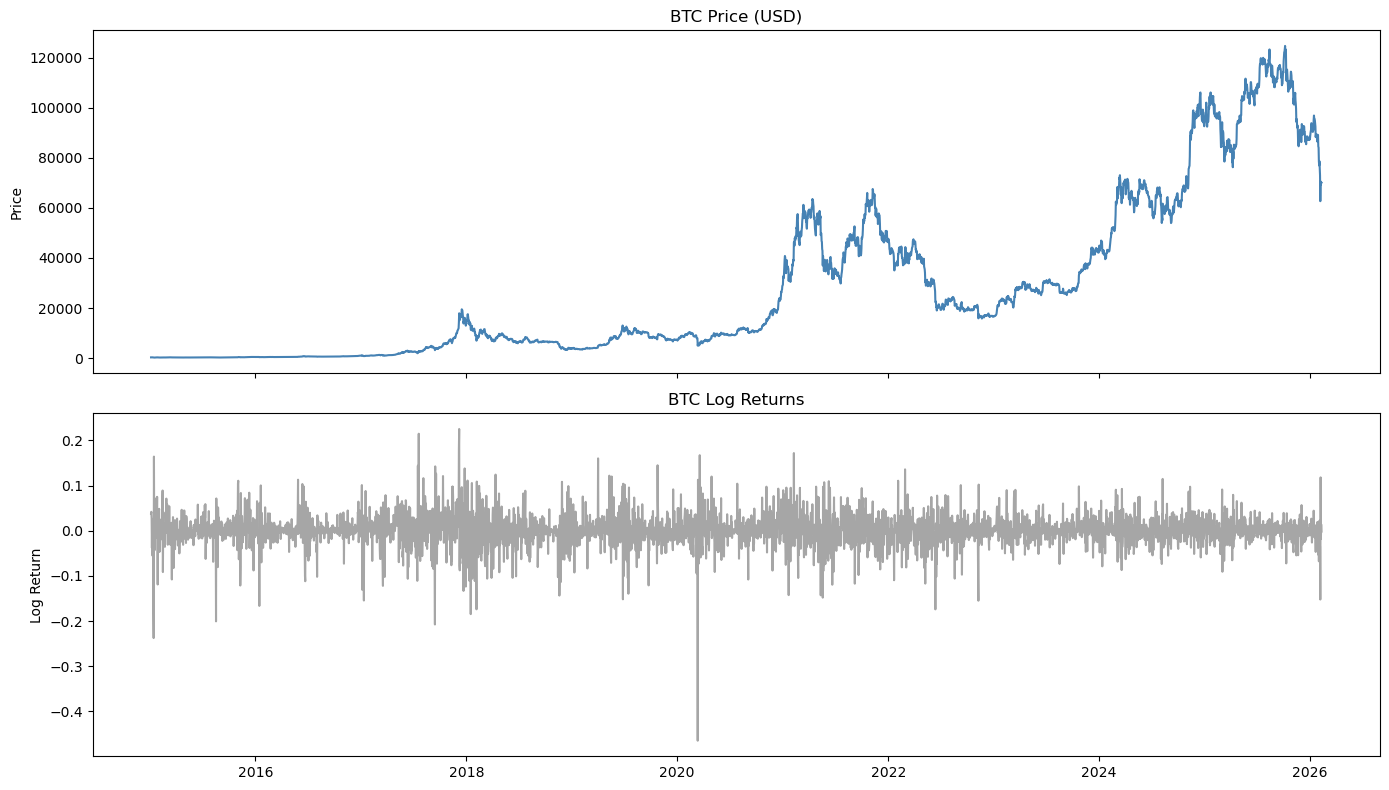

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["btc"], color="steelblue")
axes[0].set_title("BTC Price (USD)")
axes[0].set_ylabel("Price")

axes[1].plot(df.index, btc_ret, color="gray", alpha=0.7)
axes[1].set_title("BTC Log Returns")
axes[1].set_ylabel("Log Return")

plt.tight_layout()
plt.show()

---
## Part 7: 导出

保存为 CSV，供后续 GARCH/EGARCH notebook 使用。

In [15]:
out_path = OUT_DIR / "ch6_data_api.csv"
df.to_csv(out_path)
print(f"Saved to {out_path}")
print(f"Shape: {df.shape}")
print(f"Range: {df.index.min().date()} → {df.index.max().date()}")

Saved to ch6_data_api.csv
Shape: (4054, 30)
Range: 2015-01-05 → 2026-02-09


---
## Next Steps

- [x] ~~注册 FRED API key → 补上 CPI~~ ✅
- [x] ~~Google Trends (`pytrends`) → 补上情绪数据~~ ✅
- [ ] 新 notebook: EGARCH 建模（`arch` 库） → `ch6_egarch.ipynb`
- [ ] 对比新旧数据集的 EGARCH 结果